# PyTorch Foundations

6 core concepts. Each section: what it is → why it matters → code you write yourself.

1. Tensors
2. Autograd
3. nn.Module
4. DataLoader
5. Training Loop
6. Save and Load

In [22]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt

print(f"PyTorch version: {torch.__version__}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

PyTorch version: 2.11.0+cpu
Device: cpu


---
## 1. Tensors

A tensor is an n-dimensional array — the fundamental data structure in PyTorch.

- Scalar = 0D tensor
- Vector = 1D tensor
- Matrix = 2D tensor
- Image batch = 4D tensor: (batch, channels, height, width)

Tensors live on a device — CPU or GPU. Operations between tensors must be on the same device.

In [23]:
# Creating tensors
scalar = torch.tensor(3.14)
vector = torch.tensor([1.0, 2.0, 3.0])
matrix = torch.tensor([[1.0, 2.0], [3.0, 4.0]])

print(f"Scalar: {scalar}, shape: {scalar.shape}")
print(f"Vector: {vector}, shape: {vector.shape}")
print(f"Matrix:\n{matrix}, shape: {matrix.shape}")

Scalar: 3.140000104904175, shape: torch.Size([])
Vector: tensor([1., 2., 3.]), shape: torch.Size([3])
Matrix:
tensor([[1., 2.],
        [3., 4.]]), shape: torch.Size([2, 2])


In [24]:
# Common creation patterns
zeros = torch.zeros(3, 4)
ones = torch.ones(3, 4)
rand = torch.rand(3, 4)       # uniform [0, 1]
randn = torch.randn(3, 4)     # standard normal
arange = torch.arange(0, 10, 2)  # like np.arange

print(f"zeros shape: {zeros.shape}")
print(f"randn:\n{randn}")
print(f"arange: {arange}")

zeros shape: torch.Size([3, 4])
randn:
tensor([[ 0.2027,  0.0614, -0.4366,  0.6068],
        [ 1.1292, -0.3772, -0.7313,  1.0832],
        [-0.7475, -0.0622,  0.7155,  2.0679]])
arange: tensor([0, 2, 4, 6, 8])


In [25]:
# Operations
a = torch.tensor([1.0, 2.0, 3.0])
b = torch.tensor([4.0, 5.0, 6.0])

print(f"Add: {a + b}")
print(f"Multiply elementwise: {a * b}")
print(f"Dot product: {torch.dot(a, b)}")
print(f"Matrix multiply: {matrix @ matrix}")
print(f"Sum: {a.sum()}, Mean: {a.mean()}")

Add: tensor([5., 7., 9.])
Multiply elementwise: tensor([ 4., 10., 18.])
Dot product: 32.0
Matrix multiply: tensor([[ 7., 10.],
        [15., 22.]])
Sum: 6.0, Mean: 2.0


In [26]:
# Shape operations — critical for debugging
x = torch.randn(2, 3, 4)  # batch=2, features=3, time=4

print(f"Original shape: {x.shape}")
print(f"Reshape to (2, 12): {x.reshape(2, 12).shape}")
print(f"Transpose (0,2,1): {x.permute(0, 2, 1).shape}")
print(f"Squeeze/unsqueeze:")
y = x[:, :, 0]             # slice first time step
print(f"  After slice: {y.shape}")
print(f"  After unsqueeze: {y.unsqueeze(-1).shape}")

Original shape: torch.Size([2, 3, 4])
Reshape to (2, 12): torch.Size([2, 12])
Transpose (0,2,1): torch.Size([2, 4, 3])
Squeeze/unsqueeze:
  After slice: torch.Size([2, 3])
  After unsqueeze: torch.Size([2, 3, 1])


In [27]:
# Move to GPU
x_cpu = torch.randn(3, 3)
x_gpu = x_cpu.to(device)
print(f"CPU tensor device: {x_cpu.device}")
print(f"GPU tensor device: {x_gpu.device}")

# From numpy
np_array = np.array([1.0, 2.0, 3.0])
tensor_from_np = torch.from_numpy(np_array)
print(f"From numpy: {tensor_from_np}")

# To numpy
back_to_np = tensor_from_np.numpy()
print(f"Back to numpy: {back_to_np}")

CPU tensor device: cpu
GPU tensor device: cpu
From numpy: tensor([1., 2., 3.], dtype=torch.float64)
Back to numpy: [1. 2. 3.]


---
## 2. Autograd

Autograd is PyTorch's automatic differentiation engine.

When you do `requires_grad=True`, PyTorch records every operation on that tensor. When you call `.backward()`, it computes gradients through the entire computation graph using the chain rule.

This is backpropagation — implemented automatically.

**Key rule:** gradients accumulate. Call `zero_grad()` before each backward pass.

In [28]:
# Simple gradient: d/dx (x^2) = 2x
x = torch.tensor(3.0, requires_grad=True)
y = x ** 2

y.backward()  # compute dy/dx
print(f"x = {x.item()}")
print(f"y = x^2 = {y.item()}")
print(f"dy/dx = {x.grad.item()}  — should be 2x = {2*x.item()}")

x = 3.0
y = x^2 = 9.0
dy/dx = 6.0  — should be 2x = 6.0


In [29]:
# Chain rule: z = (x^2 + 1)^3, dz/dx = ?
x = torch.tensor(2.0, requires_grad=True)
z = (x**2 + 1)**3

z.backward()
# dz/dx = 3(x^2+1)^2 * 2x = 3*(4+1)^2 * 4 = 300
print(f"dz/dx = {x.grad.item()}  — should be 300")

dz/dx = 300.0  — should be 300


In [30]:
# Gradient accumulation — why zero_grad() matters
x = torch.tensor(1.0, requires_grad=True)

for i in range(3):
    y = x * 2
    y.backward()
    print(f"Step {i+1}: x.grad = {x.grad.item()}  ← accumulates without zero_grad!")

print()
x = torch.tensor(1.0, requires_grad=True)
for i in range(3):
    if x.grad is not None:
        x.grad.zero_()
    y = x * 2
    y.backward()
    print(f"Step {i+1}: x.grad = {x.grad.item()}  ← correct with zero_grad")

Step 1: x.grad = 2.0  ← accumulates without zero_grad!
Step 2: x.grad = 4.0  ← accumulates without zero_grad!
Step 3: x.grad = 6.0  ← accumulates without zero_grad!

Step 1: x.grad = 2.0  ← correct with zero_grad
Step 2: x.grad = 2.0  ← correct with zero_grad
Step 3: x.grad = 2.0  ← correct with zero_grad


In [31]:
# torch.no_grad() — disable gradient tracking for inference
x = torch.tensor(3.0, requires_grad=True)

with torch.no_grad():
    y = x ** 2
    print(f"y.requires_grad inside no_grad: {y.requires_grad}")

# Use this during evaluation — saves memory, runs faster
print("Always use torch.no_grad() during model evaluation and inference")

y.requires_grad inside no_grad: False
Always use torch.no_grad() during model evaluation and inference


---
## 3. nn.Module

`nn.Module` is the base class for all neural network models in PyTorch.

Every model you build inherits from it. Two methods you must implement:
- `__init__`: define layers
- `forward`: define how data flows through layers

PyTorch handles backward automatically — you never write the backward pass.

In [32]:
# Simple MLP — 2 hidden layers
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

model = MLP(input_dim=784, hidden_dim=256, output_dim=10)
print(model)

MLP(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=256, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=10, bias=True)
)


In [33]:
# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# Forward pass
x = torch.randn(32, 784)  # batch of 32 flattened 28x28 images
out = model(x)
print(f"Input shape: {x.shape}")
print(f"Output shape: {out.shape}")  # (32, 10) — 10 class scores per sample

Total parameters: 269,322
Trainable parameters: 269,322
Input shape: torch.Size([32, 784])
Output shape: torch.Size([32, 10])


In [34]:
# Common layers
batch_size, seq_len, embed_dim = 2, 10, 64

linear = nn.Linear(64, 32)          # fully connected
conv = nn.Conv2d(3, 16, kernel_size=3, padding=1)  # 2D convolution
bn = nn.BatchNorm2d(16)             # batch normalization after conv
dropout = nn.Dropout(p=0.5)         # dropout — only active during training
embed = nn.Embedding(vocab_size:=1000, embed_dim)  # token embeddings

# Activation functions
relu = nn.ReLU()
gelu = nn.GELU()    # used in transformers
softmax = nn.Softmax(dim=-1)

print("Linear:", linear)
print("Conv2d:", conv)
print("Embedding:", embed)

Linear: Linear(in_features=64, out_features=32, bias=True)
Conv2d: Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
Embedding: Embedding(1000, 64)


In [35]:
# model.train() vs model.eval() — critical difference
model.train()   # dropout active, BatchNorm uses batch statistics
model.eval()    # dropout disabled, BatchNorm uses running statistics

print("Always call model.eval() before inference or evaluation")
print("Always call model.train() before training loop")

Always call model.eval() before inference or evaluation
Always call model.train() before training loop


---
## 4. DataLoader

DataLoader solves two problems:
1. **Memory** — loads data in batches, not all at once
2. **GPU utilization** — prefetches next batch while GPU trains on current batch

You provide a `Dataset` (how to get one sample). DataLoader handles batching, shuffling, parallel loading.

In [36]:
# Custom Dataset — must implement __len__ and __getitem__
class SimpleDataset(Dataset):
    def __init__(self, n_samples=1000):
        self.X = torch.randn(n_samples, 10)         # 1000 samples, 10 features
        self.y = (self.X[:, 0] > 0).long()          # binary label: first feature > 0

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

dataset = SimpleDataset()
print(f"Dataset size: {len(dataset)}")
print(f"One sample — X: {dataset[0][0].shape}, y: {dataset[0][1]}")

Dataset size: 1000
One sample — X: torch.Size([10]), y: 1


In [37]:
# DataLoader
train_loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True,       # randomize order each epoch
    num_workers=2,      # parallel data loading threads
    pin_memory=True     # faster CPU→GPU transfer
)

# Iterate one batch
X_batch, y_batch = next(iter(train_loader))
print(f"Batch X shape: {X_batch.shape}")  # (32, 10)
print(f"Batch y shape: {y_batch.shape}")  # (32,)
print(f"Number of batches per epoch: {len(train_loader)}")  # 1000/32 = 32 batches

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Batch X shape: torch.Size([32, 10])
Batch y shape: torch.Size([32])
Number of batches per epoch: 32


In [38]:
# Iterate over all batches (one epoch)
total_samples = 0
for batch_idx, (X, y) in enumerate(train_loader):
    total_samples += len(X)

print(f"Total samples seen in one epoch: {total_samples}")  # should be 1000

Total samples seen in one epoch: 1000


---
## 5. Training Loop

The standard PyTorch training loop. Same skeleton for every model, every task.

```
for each epoch:
    model.train()
    for each batch:
        optimizer.zero_grad()   ← clear accumulated gradients
        outputs = model(inputs) ← forward pass
        loss = criterion(outputs, labels)
        loss.backward()         ← compute gradients
        optimizer.step()        ← update weights
    
    model.eval()
    with torch.no_grad():
        evaluate on val set
```

In [39]:
# Full training loop on our simple dataset
dataset = SimpleDataset(n_samples=2000)

# Train/val split
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Model, loss, optimizer
model = MLP(input_dim=10, hidden_dim=64, output_dim=2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Training
train_losses, val_losses, val_accs = [], [], []

for epoch in range(20):
    # --- Train ---
    model.train()
    running_loss = 0.0
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_losses.append(running_loss / len(train_loader))

    # --- Evaluate ---
    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(device), y.to(device)
            outputs = model(X)
            val_loss += criterion(outputs, y).item()
            preds = outputs.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += len(y)
    val_losses.append(val_loss / len(val_loader))
    val_accs.append(correct / total)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:2d} | Train Loss: {train_losses[-1]:.4f} | "
              f"Val Loss: {val_losses[-1]:.4f} | Val Acc: {val_accs[-1]:.3f}")

Epoch  5 | Train Loss: 0.0587 | Val Loss: 0.0632 | Val Acc: 0.988
Epoch 10 | Train Loss: 0.0229 | Val Loss: 0.0364 | Val Acc: 0.990
Epoch 15 | Train Loss: 0.0107 | Val Loss: 0.0254 | Val Acc: 0.993
Epoch 20 | Train Loss: 0.0057 | Val Loss: 0.0283 | Val Acc: 0.990


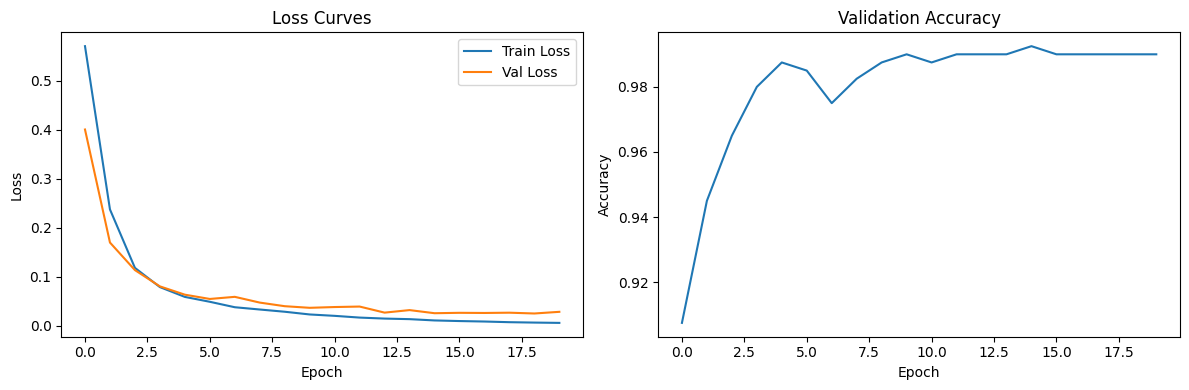

In [40]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, label='Train Loss')
ax1.plot(val_losses, label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss Curves')
ax1.legend()

ax2.plot(val_accs)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Validation Accuracy')

plt.tight_layout()
plt.show()

---
## 6. Save and Load

Two ways to save:
1. **State dict only** — recommended. Saves weights, not architecture. Portable.
2. **Entire model** — saves architecture + weights. Less portable (tied to code structure).

Always save state dict.

In [41]:
# Save state dict
torch.save(model.state_dict(), 'mlp_weights.pth')
print("Model saved.")

# Load state dict
model_loaded = MLP(input_dim=10, hidden_dim=64, output_dim=2).to(device)
model_loaded.load_state_dict(torch.load('mlp_weights.pth', map_location=device))
model_loaded.eval()
print("Model loaded.")

# Verify same output
x_test = torch.randn(1, 10).to(device)
with torch.no_grad():
    out_original = model(x_test)
    out_loaded = model_loaded(x_test)

print(f"Outputs match: {torch.allclose(out_original, out_loaded)}")

Model saved.
Model loaded.
Outputs match: True


In [42]:
# Save checkpoint — includes optimizer state for resuming training
checkpoint = {
    'epoch': 20,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'train_loss': train_losses[-1],
    'val_acc': val_accs[-1],
}
torch.save(checkpoint, 'checkpoint.pth')

# Resume from checkpoint
ckpt = torch.load('checkpoint.pth', map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
optimizer.load_state_dict(ckpt['optimizer_state_dict'])
start_epoch = ckpt['epoch']

print(f"Resumed from epoch {start_epoch}")
print(f"Last val accuracy: {ckpt['val_acc']:.3f}")

Resumed from epoch 20
Last val accuracy: 0.990


---
## Summary

| Concept | Key API | What it does |
|---|---|---|
| Tensor | `torch.tensor`, `.to(device)` | N-dimensional array, lives on CPU or GPU |
| Autograd | `requires_grad`, `.backward()`, `.grad` | Automatic gradient computation via chain rule |
| nn.Module | `__init__`, `forward`, `.to(device)` | Base class for all models — defines layers and forward pass |
| DataLoader | `Dataset`, `DataLoader(batch_size, shuffle)` | Batches data, streams from disk, parallel loading |
| Training loop | `zero_grad → forward → loss → backward → step` | The universal skeleton for training any model |
| Save/Load | `torch.save`, `torch.load`, `state_dict()` | Persist and restore model weights |

**The loop you need to explain cold in an interview:**
```python
optimizer.zero_grad()      # clear accumulated gradients
outputs = model(inputs)    # forward pass
loss = criterion(outputs, labels)
loss.backward()            # compute gradients via backprop
optimizer.step()           # update weights using gradients
```